# MF-BPR vs. LightGCN — code companion notebook

**Project 1 — Technical Review.** This notebook collects our source code
(`src/`) with brief notes: data preparation, the two models, the experiment
runner, and the cells that produce every table and figure. The detailed
discussion of the results is in the **report PDF**; here each analysis is
stated in one or two lines.

* Methods: **MF-BPR** (Rendle et al., 2009) and **LightGCN** (He et al., 2020),
  both implemented from scratch in PyTorch.
* Datasets: **MovieLens-1M** (dense) and **Amazon Reviews 2023 / Video Games**
  (144× sparser), both preprocessed to implicit feedback, 5-core, 80/10/10.
* All numbers and figures are produced by this code.

## 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()            # project1/
DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def load_result(name):
    with open(RESULTS / f"{name}.json") as f:
        return json.load(f)


## 2. Data

Sources: MovieLens-1M (`../movielens-1m/ratings.csv`, from grouplens.org) and Amazon Reviews
2023 Video Games (`../amazon-vgames-2023/ratings_part{1,2}.csv.gz`, from the
McAuley-Lab repository). Preprocessing (`src/data_prep.py`, run once with
`python3 src/data_prep.py`): implicit feedback, duplicates collapsed, iterative
5-core filter, per-user 80/10/10 random split (seed 42).

In [2]:
stats = pd.DataFrame([json.load(open(DATA / "ml-1m_stats.json")),
                      json.load(open(DATA / "vgames_stats.json"))])
stats["split"] = stats["split"].apply(lambda s: f"{s['train']:,}/{s['valid']:,}/{s['test']:,}")
stats = stats.rename(columns={"split": "train/valid/test"}).set_index("dataset")
display(stats.T)


dataset,ml-1m,vgames
interactions_after_dedup,1000209,4555500
interactions_after_5core,999611,814586
n_users,6040,94762
n_items,3416,25612
density_pct,4.8448,0.0336
avg_interactions_per_user,165.5,8.6
avg_interactions_per_item,292.63,31.8
train/valid/test,"799,821/99,895/99,895","597,090/108,748/108,748"


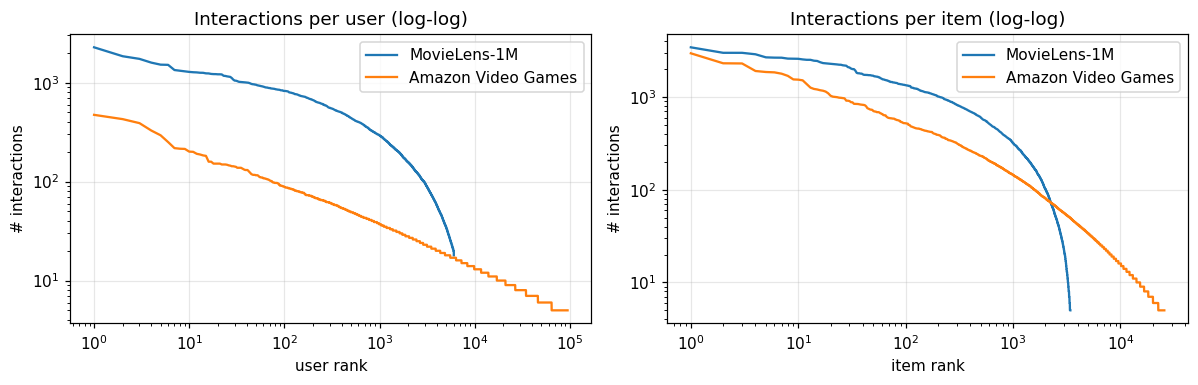

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, label in (("ml-1m", "MovieLens-1M"), ("vgames", "Amazon Video Games")):
    z = np.load(DATA / f"{name}.npz")
    allpairs = np.concatenate([z["train"], z["valid"], z["test"]])
    ucounts = np.bincount(allpairs[:, 0])
    icounts = np.bincount(allpairs[:, 1])
    for ax, cnt, what in ((axes[0], ucounts, "user"), (axes[1], icounts, "item")):
        v = np.sort(cnt)[::-1]
        ax.plot(np.arange(1, len(v) + 1), v, label=f"{label}")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(f"{what} rank"); ax.set_ylabel("# interactions")
axes[0].set_title("Interactions per user (log-log)")
axes[1].set_title("Interactions per item (log-log)")
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.savefig(FIGS / "longtail.png", bbox_inches="tight"); plt.show()


Both datasets are long-tailed; the average user has 165 interactions on
MovieLens-1M vs. 8.6 on Video Games — the key experimental variable of the study.

## 3. Models (`src/models.py`)

Both models score a user–item pair by a dot product of embeddings and train with
the BPR pairwise loss. **The only difference** is how final embeddings are
produced: MF uses the free embedding tables; LightGCN averages 0..L hops of
propagation over the user–item graph. Full source:

In [4]:
"""MF-BPR and LightGCN implemented from scratch in PyTorch.

Both models learn one embedding per user and per item, score a (user, item)
pair by the dot product, and are trained with the BPR pairwise ranking loss.
The ONLY difference is how the final embeddings are produced:

  MF-BPR  : final embedding = the free embedding table itself.
  LightGCN: final embedding = mean of the embeddings propagated 0..L hops
            over the user-item interaction graph (He et al., SIGIR 2020).

LightGCN propagation is implemented with gather + index_add over the edge
list, which runs on CPU and Apple-Silicon MPS alike (sparse matmul does not).
"""
import torch
import torch.nn as nn


class MFBPR(nn.Module):
    def __init__(self, n_users: int, n_items: int, dim: int):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_emb = nn.Embedding(n_items, dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def final_embeddings(self):
        return self.user_emb.weight, self.item_emb.weight

    def ego_embeddings(self, users, pos, neg):
        """Embeddings used for L2 regularization (the free parameters)."""
        return self.user_emb(users), self.item_emb(pos), self.item_emb(neg)


class LightGCN(nn.Module):
    def __init__(self, n_users: int, n_items: int, dim: int, n_layers: int,
                 train_edges: torch.Tensor):
        """train_edges: LongTensor (E, 2) of (user_idx, item_idx) train pairs."""
        super().__init__()
        self.n_users, self.n_items, self.n_layers = n_users, n_items, n_layers
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_emb = nn.Embedding(n_items, dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

        # Bidirectional edges on the joint (users + items) node index space,
        # with symmetric normalization 1 / sqrt(deg_u * deg_i).
        u, i = train_edges[:, 0], train_edges[:, 1] + n_users
        deg = torch.zeros(n_users + n_items)
        deg.index_add_(0, u, torch.ones(len(u)))
        deg.index_add_(0, i, torch.ones(len(i)))
        w = (deg[u] * deg[i]).clamp(min=1).rsqrt()
        self.register_buffer("src", torch.cat([u, i]))
        self.register_buffer("dst", torch.cat([i, u]))
        self.register_buffer("w", torch.cat([w, w]).unsqueeze(1))

    def propagate(self):
        x = torch.cat([self.user_emb.weight, self.item_emb.weight])
        acc = x
        for _ in range(self.n_layers):
            msg = x[self.src] * self.w
            x = torch.zeros_like(x).index_add_(0, self.dst, msg)
            acc = acc + x
        out = acc / (self.n_layers + 1)          # mean over layers 0..L
        return out[:self.n_users], out[self.n_users:]

    def final_embeddings(self):
        return self.propagate()

    def ego_embeddings(self, users, pos, neg):
        return self.user_emb(users), self.item_emb(pos), self.item_emb(neg)


def bpr_loss(user_e, pos_e, neg_e, ego, reg: float):
    """BPR loss + L2 regularization on the ego (free) embeddings."""
    pos_s = (user_e * pos_e).sum(-1)
    neg_s = (user_e * neg_e).sum(-1)
    loss = -nn.functional.logsigmoid(pos_s - neg_s).mean()
    l2 = sum((e ** 2).sum() for e in ego) / len(user_e)
    return loss + reg * l2

## 4. Training and evaluation (`src/train.py`)

BPR training with 1 uniform negative per positive; full-ranking evaluation
(Recall@K / NDCG@K over all non-train items); early stopping on validation
NDCG@10 (patience 30 epochs). Budget: 300 epochs for MF, 600 for LightGCN
(it converges more slowly — see report). Devices: CUDA / Apple-MPS / CPU.

Reproduce everything with:

```bash
python3 src/data_prep.py      # once
bash src/run_all.sh           # all runs; ~1.5 h on one NVIDIA L4
```

Each run writes `results/<name>.json` (config, history, best validation and
test metrics); main runs also save embeddings and top-K lists for analysis.

## 5. Results

### 5.1 Main comparison (test set, dim 64)

In [5]:
runs = {
    ("MovieLens-1M", "MF-BPR"): "ml-1m_mf_d64",
    ("MovieLens-1M", "LightGCN (3 layers)"): "ml-1m_lightgcn_d64_l3",
    ("Video Games", "MF-BPR"): "vgames_mf_d64",
    ("Video Games", "LightGCN (3 layers)"): "vgames_lightgcn_d64_l3",
}
rows = []
for (ds, model), name in runs.items():
    r = load_result(name)
    rows.append({"dataset": ds, "model": model, **r["test"],
                 "best_epoch": r["best_epoch"],
                 "train_min": round(r["train_seconds"] / 60, 1)})
main = pd.DataFrame(rows).set_index(["dataset", "model"])
display(main.round(4))

for ds in ("MovieLens-1M", "Video Games"):
    mf = main.loc[(ds, "MF-BPR")]
    lg = main.loc[(ds, "LightGCN (3 layers)")]
    for m in ("recall@20", "ndcg@10"):
        gain = 100 * (lg[m] - mf[m]) / mf[m]
        print(f"{ds:14s} {m:10s} MF {mf[m]:.4f} -> LightGCN {lg[m]:.4f} ({gain:+.1f}%)")


recall@10  ndcg@10  recall@20  ndcg@20  \
dataset      model                                                         
MovieLens-1M MF-BPR                  0.1560   0.2456     0.2384   0.2525   
             LightGCN (3 layers)     0.1728   0.2605     0.2638   0.2709   
Video Games  MF-BPR                  0.0634   0.0344     0.0969   0.0431   
             LightGCN (3 layers)     0.0907   0.0494     0.1349   0.0608   

                                  best_epoch  train_min  
dataset      model                                       
MovieLens-1M MF-BPR                       45        0.5  
             LightGCN (3 layers)         450        6.5  
Video Games  MF-BPR                      125        4.0  
             LightGCN (3 layers)         565       17.4

MovieLens-1M   recall@20  MF 0.2384 -> LightGCN 0.2638 (+10.6%)
MovieLens-1M   ndcg@10    MF 0.2456 -> LightGCN 0.2605 (+6.1%)
Video Games    recall@20  MF 0.0969 -> LightGCN 0.1349 (+39.3%)
Video Games    ndcg@10    MF 0.0344 -> LightGCN 0.0494 (+43.5%)


### 5.2 Convergence (validation NDCG@10 per epoch)

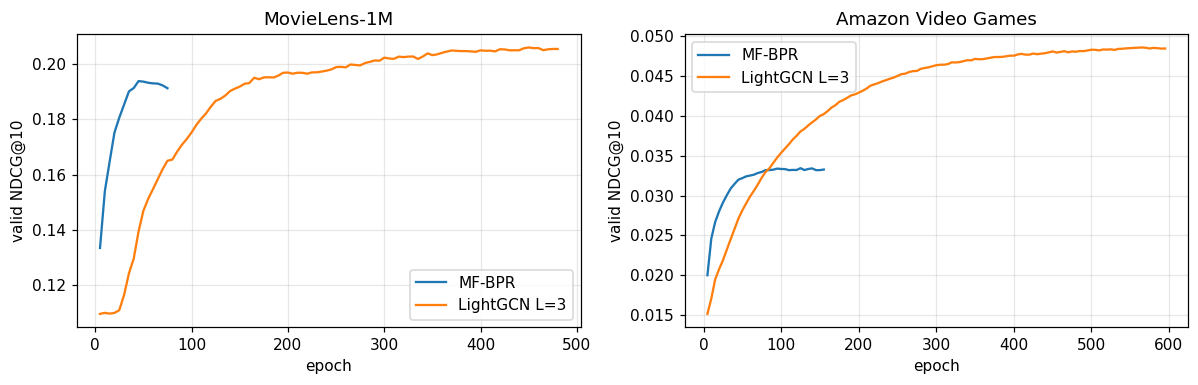

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, ds, title in ((axes[0], "ml-1m", "MovieLens-1M"),
                      (axes[1], "vgames", "Amazon Video Games")):
    for model, label in (("mf_d64", "MF-BPR"), ("lightgcn_d64_l3", "LightGCN L=3")):
        h = load_result(f"{ds}_{model}")["history"]
        ax.plot([e["epoch"] for e in h], [e["ndcg@10"] for e in h], label=label)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("valid NDCG@10")
    ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "convergence.png", bbox_inches="tight"); plt.show()


### 5.3 Training loss (BPR) per epoch

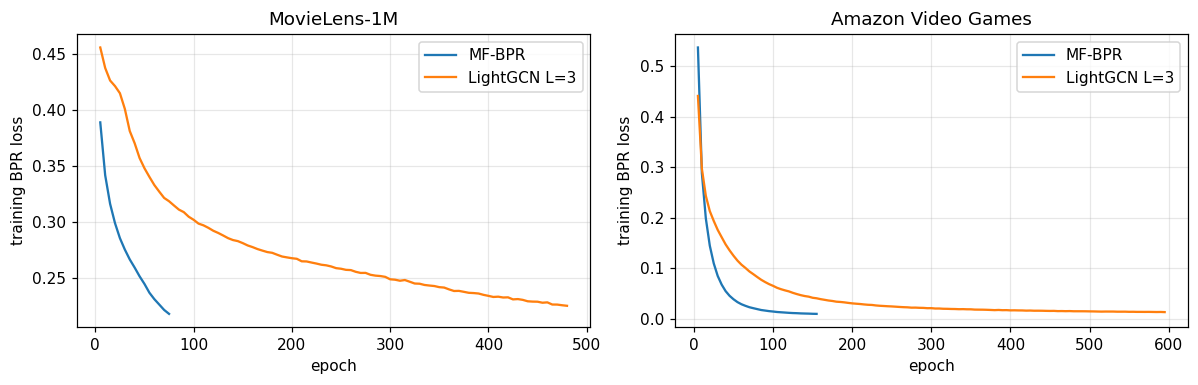

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ds, title in ((axes[0], "ml-1m", "MovieLens-1M"),
                      (axes[1], "vgames", "Amazon Video Games")):
    for model, label in (("mf_d64", "MF-BPR"), ("lightgcn_d64_l3", "LightGCN L=3")):
        h = load_result(f"{ds}_{model}")["history"]
        ax.plot([e["epoch"] for e in h], [e["loss"] for e in h], label=label)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("training BPR loss")
    ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "loss_curves.png", bbox_inches="tight"); plt.show()


### 5.4 Ablation: propagation layers L (fair 600-epoch budget for every L)

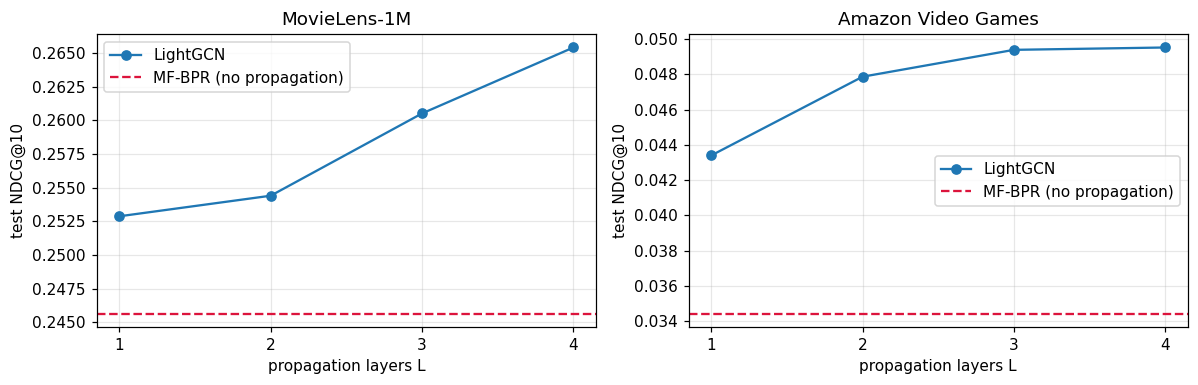

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ds, title in ((axes[0], "ml-1m", "MovieLens-1M"),
                      (axes[1], "vgames", "Amazon Video Games")):
    xs, ys = [], []
    for L in (1, 2, 3, 4):
        r = load_result(f"{ds}_lightgcn_d64_l{L}")
        xs.append(L); ys.append(r["test"]["ndcg@10"])
    mf = load_result(f"{ds}_mf_d64")["test"]["ndcg@10"]
    ax.plot(xs, ys, "o-", label="LightGCN")
    ax.axhline(mf, color="crimson", ls="--", label="MF-BPR (no propagation)")
    ax.set_title(title); ax.set_xlabel("propagation layers L"); ax.set_ylabel("test NDCG@10")
    ax.set_xticks(xs); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "ablation_layers.png", bbox_inches="tight"); plt.show()


### 5.5 Embedding dimension sweep

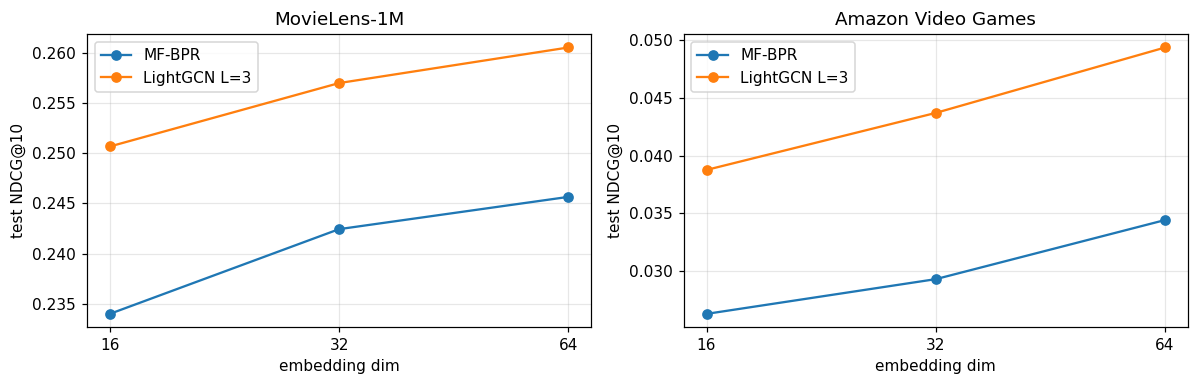

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ds, title in ((axes[0], "ml-1m", "MovieLens-1M"),
                      (axes[1], "vgames", "Amazon Video Games")):
    for model, label in (("mf_d{d}", "MF-BPR"), ("lightgcn_d{d}_l3", "LightGCN L=3")):
        dims, ys = [16, 32, 64], []
        for d in dims:
            ys.append(load_result(f"{ds}_{model.format(d=d)}")["test"]["ndcg@10"])
        ax.plot(dims, ys, "o-", label=label)
    ax.set_title(title); ax.set_xlabel("embedding dim"); ax.set_ylabel("test NDCG@10")
    ax.set_xscale("log", base=2); ax.set_xticks([16, 32, 64], [16, 32, 64]); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "dim_sweep.png", bbox_inches="tight"); plt.show()


## 6. Analysis

### 6.1 Recall@20 by user-activity bucket (does the graph help cold users most?)

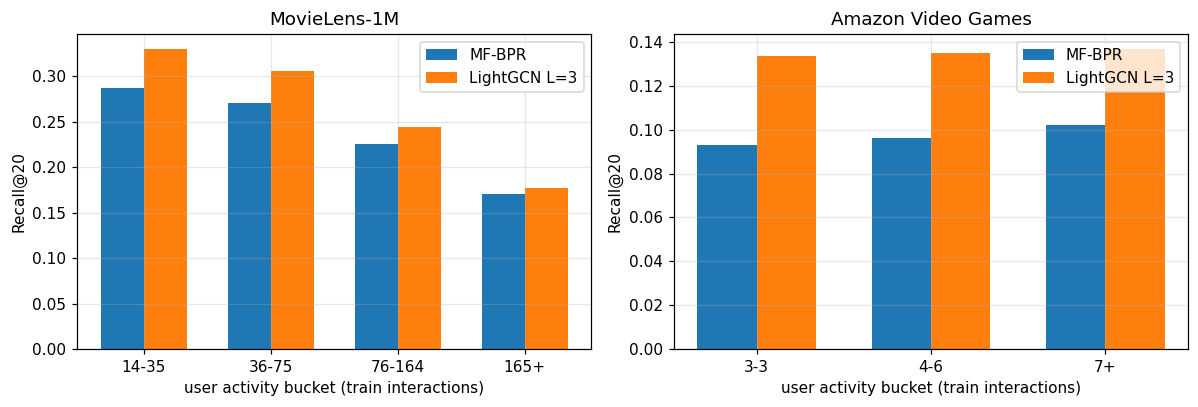

In [10]:
def per_user_recall(topk, test_by_user, k=20):
    out = np.full(len(test_by_user), np.nan)
    for u, pos in enumerate(test_by_user):
        if len(pos):
            out[u] = len(set(topk[u, :k]) & set(pos)) / len(pos)
    return out

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, ds, title in ((axes[0], "ml-1m", "MovieLens-1M"),
                      (axes[1], "vgames", "Amazon Video Games")):
    z = np.load(DATA / f"{ds}.npz")
    n_users = int(z["n_users"])
    train_deg = np.bincount(z["train"][:, 0], minlength=n_users)
    test_by_user = [[] for _ in range(n_users)]
    for u, i in z["test"]:
        test_by_user[u].append(i)
    recs = {}
    for model, label in (("mf_d64", "MF-BPR"), ("lightgcn_d64_l3", "LightGCN L=3")):
        topk = np.load(RESULTS / f"{ds}_{model}_emb.npz")["topk"]
        recs[label] = per_user_recall(topk, test_by_user)
    # Quantile-based degree bins; np.unique guards against degenerate
    # quantiles on Video Games, where most users have only 3-7 interactions.
    edges = np.unique(np.quantile(train_deg, [0, .25, .5, .75, 1.0]).astype(int))
    bins = [(edges[j], edges[j + 1]) for j in range(len(edges) - 1)]
    labels_q = [f"{lo}-{hi - 1}" if j < len(bins) - 1 else f"{lo}+"
                for j, (lo, hi) in enumerate(bins)]
    x = np.arange(len(bins))
    for off, (label, r) in zip((-0.17, 0.17), recs.items()):
        means = []
        for j, (lo, hi) in enumerate(bins):
            mask = (train_deg >= lo) & ((train_deg < hi) | (j == len(bins) - 1))
            means.append(np.nanmean(r[mask]))
        ax.bar(x + off, means, width=0.34, label=label)
    ax.set_xticks(x, labels_q); ax.set_ylabel("Recall@20")
    ax.set_xlabel("user activity bucket (train interactions)")
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "activity_buckets.png", bbox_inches="tight"); plt.show()


### 6.2 Popularity of recommendations and catalog coverage

In [11]:
rows = []
for ds, title in (("ml-1m", "MovieLens-1M"), ("vgames", "Video Games")):
    z = np.load(DATA / f"{ds}.npz")
    item_pop = np.bincount(z["train"][:, 1], minlength=int(z["n_items"]))
    for model, label in (("mf_d64", "MF-BPR"), ("lightgcn_d64_l3", "LightGCN L=3")):
        topk = np.load(RESULTS / f"{ds}_{model}_emb.npz")["topk"][:, :10]
        rows.append({
            "dataset": title, "model": label,
            "mean pop. of recommended items": round(float(item_pop[topk].mean()), 1),
            "catalog coverage@10 (%)": round(100 * len(np.unique(topk)) / len(item_pop), 1),
        })
    rows.append({"dataset": title, "model": "(train set avg item pop.)",
                 "mean pop. of recommended items": round(float(item_pop[z['train'][:,1]].mean()), 1),
                 "catalog coverage@10 (%)": np.nan})
display(pd.DataFrame(rows).set_index(["dataset", "model"]))


mean pop. of recommended items  \
dataset      model                                                       
MovieLens-1M MF-BPR                                             1150.0   
             LightGCN L=3                                        993.7   
             (train set avg item pop.)                           654.2   
Video Games  MF-BPR                                              372.7   
             LightGCN L=3                                        417.8   
             (train set avg item pop.)                           162.9   

                                        catalog coverage@10 (%)  
dataset      model                                               
MovieLens-1M MF-BPR                                        50.9  
             LightGCN L=3                                  61.4  
             (train set avg item pop.)                      NaN  
Video Games  MF-BPR                                        62.1  
             LightGCN L=3                                  41.4  
             (train set avg item pop.)                      NaN

### 6.3 Case study (MovieLens-1M): one cold and one heavy user

In [12]:
movies = pd.read_csv(ROOT.parent / "movielens-1m" / "movies.csv")
z = np.load(DATA / "ml-1m.npz")
n_users = int(z["n_users"])
train_deg = np.bincount(z["train"][:, 0], minlength=n_users)

# Reconstruct the item-id mapping used by data_prep (sorted raw ids).
ml = pd.read_csv(ROOT.parent / "movielens-1m" / "ratings.csv", usecols=["user_id", "movie_id"])
ml.columns = ["user", "item"]
ml = ml.drop_duplicates()
# apply same 5-core as data_prep
def k_core5(df):
    while True:
        uc = df["user"].map(df["user"].value_counts())
        ic = df["item"].map(df["item"].value_counts())
        keep = (uc >= 5) & (ic >= 5)
        if keep.all():
            return df
        df = df[keep]
ml = k_core5(ml)
item_raw = np.array(sorted(ml["item"].unique()))
title_of = movies.set_index("movie_id")["title"]
genre_of = movies.set_index("movie_id")["genres"]

test_by_user = [[] for _ in range(n_users)]
for u, i in z["test"]:
    test_by_user[u].append(i)
train_by_user = [[] for _ in range(n_users)]
for u, i in z["train"]:
    train_by_user[u].append(i)

topk = {m: np.load(RESULTS / f"ml-1m_{m}_emb.npz")["topk"] for m in ("mf_d64", "lightgcn_d64_l3")}

rng = np.random.default_rng(0)
cold = rng.choice(np.where(train_deg <= np.quantile(train_deg, 0.1))[0])
heavy = rng.choice(np.where(train_deg >= np.quantile(train_deg, 0.95))[0])

for u, kind in ((cold, "LOW-activity"), ((heavy), "HIGH-activity")):
    print(f"=== {kind} user (internal id {u}, {train_deg[u]} train interactions) ===")
    hist_genres = pd.Series([g for i in train_by_user[u]
                             for g in genre_of[item_raw[i]].split("|")]).value_counts()
    print("train-history genres:", dict(hist_genres.head(5)))
    test_set = set(test_by_user[u])
    for m, label in (("mf_d64", "MF-BPR"), ("lightgcn_d64_l3", "LightGCN")):
        print(f"-- {label} top-10 --")
        for i in topk[m][u, :10]:
            hit = "  <-- HELD-OUT HIT" if i in test_set else ""
            print(f"   {title_of[item_raw[i]]}{hit}")
    print()


=== LOW-activity user (internal id 4987, 20 train interactions) ===
train-history genres: {'Drama': 9, 'Comedy': 6, 'Romance': 4, 'Action': 3, 'Crime': 3}
-- MF-BPR top-10 --
   American Beauty (1999)
   Groundhog Day (1993)
   Being John Malkovich (1999)
   Toy Story (1995)
   Schindler's List (1993)
   Fargo (1996)  <-- HELD-OUT HIT
   Princess Bride, The (1987)
   L.A. Confidential (1997)
   Star Wars: Episode V - The Empire Strikes Back (1980)
   Shawshank Redemption, The (1994)
-- LightGCN top-10 --
   American Beauty (1999)
   Toy Story (1995)
   Fargo (1996)  <-- HELD-OUT HIT
   Being John Malkovich (1999)
   L.A. Confidential (1997)
   Shawshank Redemption, The (1994)
   Schindler's List (1993)
   GoodFellas (1990)
   Toy Story 2 (1999)
   Silence of the Lambs, The (1991)

=== HIGH-activity user (internal id 3692, 476 train interactions) ===
train-history genres: {'Comedy': 171, 'Drama': 162, 'Action': 116, 'Thriller': 90, 'Romance': 73}
-- MF-BPR top-10 --
   Star Wars: Episod

## 7. Conclusions (summary — full discussion in the report PDF)

1. LightGCN beats MF-BPR on both datasets: **+6.1%** NDCG@10 on dense
   MovieLens-1M, **+43.6%** on the 144×-sparser Video Games.
2. The gain concentrates on **low-activity users** (+14.6% → +3.9% across
   ML-1M activity quartiles).
3. On dense data LightGCN *lowers* popularity bias and raises coverage; on
   sparse data it does the opposite (coverage 62% → 41%).
4. No over-smoothing up to L=4 under a fair 600-epoch budget; the apparent
   "shallow-L peak" at 300 epochs was a training-budget artifact.
5. LightGCN at d=16 beats MF at d=64 (parameter efficiency), but needs ~10×
   the training compute to converge.

## 8. Repository layout

```
project1/
├── src/data_prep.py        # preprocessing
├── src/models.py           # MF-BPR + LightGCN (shown in Section 3)
├── src/train.py            # training / evaluation CLI
├── src/run_all.sh          # full experiment queue
├── data/                   # processed splits (npz) + stats
├── results/                # one JSON log (+ embeddings) per run
├── figures/                # all figures produced by this notebook
└── report/                 # LaTeX source of the report PDF
```

Environment: Python 3.9+, `torch`, `pandas`, `numpy`, `matplotlib`. Seed 42;
identical MF metrics verified across Apple-M2 (MPS) and NVIDIA L4 (CUDA).